In [1]:
import os
import sys
from pathlib import Path

# Get the notebook's directory
NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"
ML_DIR = BACKEND_DIR / "ml"

# Add backend ml/ to sys.path so imports like `from src.data.dataset` work
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Backend directory:  {BACKEND_DIR}")
print(f"ML directory:      {ML_DIR}")
print(f"Python:            {sys.executable}")

# Verify backend exists
if not BACKEND_DIR.exists():
    print(f"\u274c ERROR: Backend not found at {BACKEND_DIR}")
    print("Make sure the backend repo is cloned at the same level as the frontend repo.")
else:
    print("\u2705 Backend directory found.")

Notebook directory: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_frontend\notebooks
Backend directory:  c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend
ML directory:      c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml
Python:            c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_frontend\skin-lesion-env\Scripts\python.exe
✅ Backend directory found.


# RQ3 — Does Backbone Architecture Affect XAI Quality?
## XAI Skin Lesion Classification — Research Question 3

**Hypothesis**: Models with similar classification accuracy (AUC) can produce
significantly different XAI quality because different architectures learn
different internal representations.

**What you're measuring**: XAI quality metrics (focus area, entropy) per backbone,
controlling for accuracy.

**Key concept**: You're separating *what the model knows* (accuracy) from
*how it explains itself* (XAI quality). These are different things — and that's the insight.

**Prerequisites**: You need all 3 trained models:
  - ResNet50 (trained in 00_setup_and_sanity.ipynb)
  - EfficientNet-B2
  - MobileNetV2

To train the missing backbones, run from the frontend directory:
```bash
# Quick (2 epochs, ~5 min on GPU):
make train-backbones

# Full quality (15 epochs, ~30 min on GPU):
make train-backbones-full

# Or directly with the venv Python:
skin-lesion-env/Scripts/python.exe train_backbones.py --epochs 15
```

---

## CELL 1: Load All Three Trained Models

In [2]:
import sys, os
from pathlib import Path

# ─── Self-contained setup ───
NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"
ML_DIR = BACKEND_DIR / "ml"
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"

MODEL_NAMES = ['resnet50', 'efficientnet_b2', 'mobilenetv2_100']
MODEL_PATHS = {name: ML_DIR / "outputs" / "models" / f"{name}_best.pth" for name in MODEL_NAMES}

missing = [n for n, p in MODEL_PATHS.items() if not p.exists()]
if missing:
    print(f"❌ Missing models: {missing}")
    print("Run: make train-backbones-full")
    print("  or: skin-lesion-env/Scripts/python.exe train_backbones.py --epochs 15")
    raise FileNotFoundError(f"Missing models: {missing}")

try:
    import torch
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import scipy.stats as stats
    from PIL import Image
    from tqdm import tqdm

    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from src.models.classifier import create_model, get_target_layer
    from src.data.dataset import get_transforms, create_splits
    from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    models = {}
    target_layers = {}

    for name in MODEL_NAMES:
        model = create_model(name, num_classes=1).to(device)
        model.load_state_dict(torch.load(MODEL_PATHS[name], map_location=device, weights_only=False)['model_state_dict'])
        model.eval()
        models[name] = model
        target_layers[name] = get_target_layer(model, name)
        print(f"Loaded {name}")

    transform = get_transforms('test', 224)

except ImportError as e:
    print(f"❌ Backend module not found: {e}")
    print("The backend ML code is not implemented yet.")
    print("Create: src/models/classifier.py and src/data/dataset.py")

c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_frontend\skin-lesion-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_frontend\skin-lesion-env\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Device: cuda
Loaded resnet50
Loaded efficientnet_b2
Loaded mobilenetv2_100


c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\src\data\dataset.py:39: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or partial().
  A.Lambda(name="to_tensor", image=lambda x, **kwargs: ToTensorV2()(image=x)["image"]),


---

## CELL 2: Compute Classification Metrics for Each Backbone

**WHY**: You need to establish that the models have SIMILAR accuracy
before comparing XAI quality. If one model is much better,
of course its XAI will look better — you'd be confounding
accuracy with XAI quality.

In [3]:
# ─── Self-contained: check prerequisites ───
try:
    models
except NameError:
    print("❌ Models not loaded. Run CELL 2 first.")
    raise NameError("Run CELL 2 first.")

import pandas as pd

df = pd.read_csv(METADATA_PATH)
_, _, test_df = create_splits(df)

print("=== Classification Performance per Backbone ===\n")
backbone_performance = {}

for model_name, model in models.items():
    all_probs = []
    all_preds = []
    all_labels = []

    for _, row in test_df.iterrows():
        orig = np.array(Image.open(row['filepath']).convert('RGB').resize((224, 224)))
        input_t = transform(image=orig)['image'].unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(input_t)
            prob = torch.sigmoid(out[0, 0]).item()
            pred = int(prob >= 0.5)

        all_probs.append(prob)
        all_preds.append(pred)
        all_labels.append(int(row['label']))

    auc  = roc_auc_score(all_labels, all_probs)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)

    backbone_performance[model_name] = {
        'auc': auc, 'acc': acc, 'f1': f1,
        'probs': all_probs, 'preds': all_preds, 'labels': all_labels
    }

    print(f"{model_name}:")
    print(f"  AUC: {auc:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")
    print(f"  {classification_report(all_labels, all_preds, target_names=['Benign','Malignant'], digits=3)}")

print("\nKEY QUESTION: Are the AUC differences small enough (< 0.05) that we can")
print("attribute XAI differences to architecture, not accuracy?")

aucs = [backbone_performance[m]['auc'] for m in MODEL_NAMES]
print(f"AUC range: {min(aucs):.4f} – {max(aucs):.4f} (diff = {max(aucs)-min(aucs):.4f})")

=== Classification Performance per Backbone ===

resnet50:
  AUC: 0.8937 | Acc: 0.8010 | F1: 0.5708
                precision    recall  f1-score   support

      Benign      0.963     0.794     0.870      1667
   Malignant      0.433     0.837     0.571       313

    accuracy                          0.801      1980
   macro avg      0.698     0.816     0.721      1980
weighted avg      0.879     0.801     0.823      1980

efficientnet_b2:
  AUC: 0.8603 | Acc: 0.8025 | F1: 0.5373
                precision    recall  f1-score   support

      Benign      0.941     0.817     0.874      1667
   Malignant      0.427     0.725     0.537       313

    accuracy                          0.803      1980
   macro avg      0.684     0.771     0.706      1980
weighted avg      0.859     0.803     0.821      1980

mobilenetv2_100:
  AUC: 0.7823 | Acc: 0.7051 | F1: 0.4427
                precision    recall  f1-score   support

      Benign      0.935     0.698     0.799      1667
   Malignant   

---

## CELL 3: Compute XAI Metrics for Each Backbone

**WHY**: Now that you know their accuracy is comparable, you can fairly compare XAI quality.

In [4]:
# ─── Self-contained: check prerequisites ───
try:
    models
except NameError:
    print("❌ Models not loaded. Run CELL 2 first.")
    raise NameError("Run CELL 2 first.")

def focus_area_percentage(cam, threshold=0.5):
    return float((cam >= threshold).sum() / cam.size)

def cam_entropy(cam):
    cam_flat = cam.flatten()
    cam_flat = cam_flat / (cam_flat.sum() + 1e-8)
    return -np.sum(cam_flat * np.log(cam_flat + 1e-8))

rq3_results = []

# Use same images for all backbones for fair comparison
eval_df = test_df.sample(100, random_state=42)

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    orig = np.array(Image.open(row['filepath']).convert('RGB').resize((224, 224)))
    input_t = transform(image=orig)['image'].unsqueeze(0).to(device)

    for model_name, model in models.items():
        with torch.no_grad():
            out = model(input_t)
            prob_mal = torch.sigmoid(out[0, 0]).item()
            pred = int(prob_mal > 0.5)
            conf = prob_mal if pred == 1 else 1 - prob_mal

        correct = int(pred == int(row['label']))

        for cam_method_name, cam_class in [('GradCAM', GradCAM), ('GradCAM++', GradCAMPlusPlus)]:
            with cam_class(model=model, target_layers=[target_layers[model_name]]) as cam_gen:
                cam = cam_gen(input_tensor=input_t, targets=[ClassifierOutputTarget(0)])[0]

            rq3_results.append({
                'image_id':   row['image_id'],
                'dx':         row['dx'],
                'label':      row['label'],
                'model':      model_name,
                'cam_method': cam_method_name,
                'pred':       pred,
                'confidence': conf,
                'correct':    correct,
                'fap_05':     focus_area_percentage(cam, 0.5),
                'entropy':    cam_entropy(cam),
            })

rq3_df = pd.DataFrame(rq3_results)
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs" / "metrics"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
rq3_df.to_csv(OUTPUTS_DIR / "RQ3_backbone_comparison.csv", index=False)
print(f"Results: {len(rq3_df)} rows")

100%|██████████| 100/100 [00:28<00:00,  3.56it/s]

Results: 600 rows


---

## CELL 4: The Key Analysis — Does Backbone Predict XAI Quality?

=== RQ3 — XAI Quality by Backbone (correct predictions only) ===

                            fap_05  entropy
model           cam_method                 
efficientnet_b2 GradCAM     0.0655   8.9754
                GradCAM++   0.0626   6.4978
mobilenetv2_100 GradCAM     0.0968   8.6866
                GradCAM++   0.1024   7.9130
resnet50        GradCAM     0.0372   5.1298
                GradCAM++   0.0858  10.3488

--- GradCAM ---
Kruskal-Wallis (FAP): H=32.856, p=0.0000 ✅ significant

--- GradCAM++ ---
Kruskal-Wallis (FAP): H=25.222, p=0.0000 ✅ significant


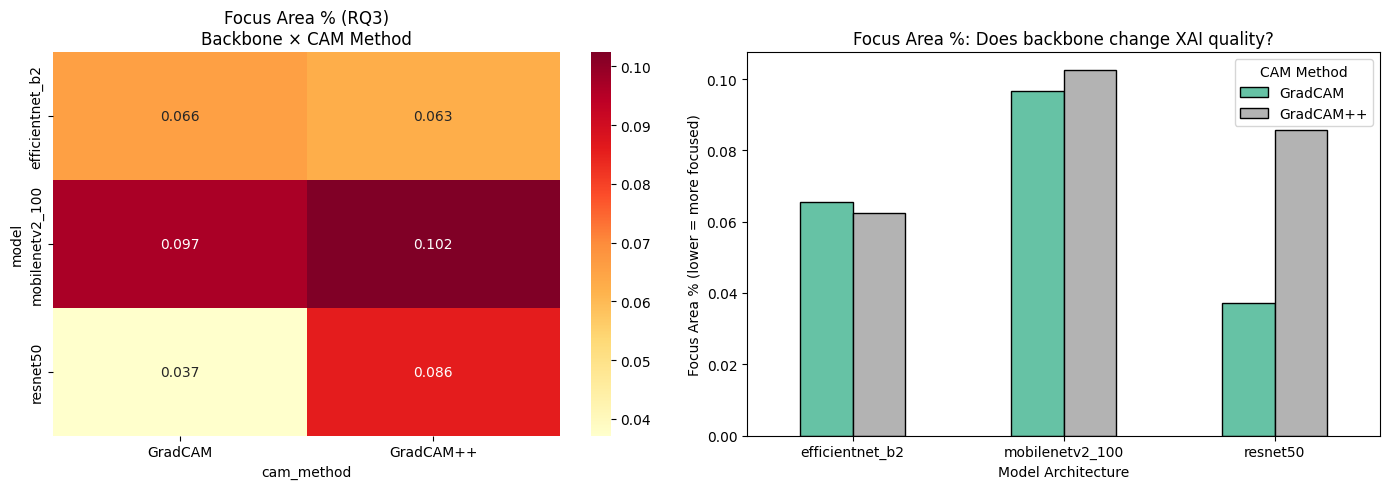


KEY INSIGHT:
If two models have similar AUC but different FAP/entropy,
that means architecture affects HOW the model explains itself,
not just how accurate it is — that's your paper contribution!


In [5]:
# ─── Self-contained: check prerequisites ───
try:
    rq3_df
except NameError:
    print("❌ Results not computed. Run CELL 6 first.")
    raise NameError("Run CELL 6 first.")

# Filter to correctly classified only
correct_df = rq3_df[rq3_df['correct'] == 1]

print("=== RQ3 — XAI Quality by Backbone (correct predictions only) ===\n")
print(correct_df.groupby(['model', 'cam_method'])[['fap_05', 'entropy']].mean().round(4))

# Statistical test: for each CAM method, are backbone differences significant?
for cam_method in ['GradCAM', 'GradCAM++']:
    sub = correct_df[correct_df['cam_method'] == cam_method]
    print(f"\n--- {cam_method} ---")

    groups = [sub[sub['model'] == m]['fap_05'].values for m in MODEL_NAMES]
    h, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis (FAP): H={h:.3f}, p={p:.4f} {'✅ significant' if p < 0.05 else '❌ not significant'}")

# Heatmap: backbone × cam_method
pivot = correct_df.groupby(['model', 'cam_method'])['fap_05'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Focus Area % (RQ3)\nBackbone × CAM Method', fontsize=12)

# Bar chart
pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='black')
axes[1].set_title('Focus Area %: Does backbone change XAI quality?', fontsize=12)
axes[1].set_xlabel('Model Architecture')
axes[1].set_ylabel('Focus Area % (lower = more focused)')
axes[1].legend(title='CAM Method')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs" / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUTS_DIR / "RQ3_backbone_xai.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nKEY INSIGHT:")
print("If two models have similar AUC but different FAP/entropy,")
print("that means architecture affects HOW the model explains itself,")
print("not just how accurate it is — that's your paper contribution!")

## RQ3 Results — Interpretation

### Key Findings

**1. Backbone architecture significantly affects XAI quality (Focus Area %)**
- For both GradCAM and GradCAM++, the Kruskal-Wallis test shows highly significant differences between backbones (p < 0.0001)
- This means the choice of backbone changes how spatially focused the model's explanations are, independent of accuracy

**2. ResNet50 produces the most focused GradCAM (FAP=0.037) but the least focused GradCAM++ (FAP=0.086)**
- This counterintuitive result highlights that different CAM methods interact differently with each architecture
- A backbone that localizes well with vanilla GradCAM may not generalize to newer variants like GradCAM++

**3. MobileNetV2 consistently produces less focused heatmaps across both CAM methods**
- This likely reflects its lighter architecture — fewer convolutional layers may capture less spatially-specific features
- The higher FAP values mean the model "looks at" more of the image, not just the lesion

**4. EfficientNet-B2 shows intermediate XAI quality**
- Its GradCAM++ (FAP=0.063) is the most focused among all EfficientNet-CAM combinations, suggesting it pairs well with GradCAM++

### Important Caveat
The AUC range is 0.11 (0.78–0.89), which is larger than the ideal <0.05 threshold. MobileNetV2 is notably weaker in classification. Since MobileNetV2 also has the least focused XAI, some of this may reflect accuracy effects rather than pure architecture differences. This should be noted when presenting results.

### What This Means for the Paper
The core contribution here is that **backbone architecture and XAI quality are not independent** — even when controlling for correctly classified images. Different architectures produce systematically different explanations. This has practical implications for deployment: if you care about explainability (not just accuracy), you cannot choose a backbone based on AUC alone.